# Data Inspection: FracTracker Data Centers and Political Data

## DSCI 591 Capstone: Data Center Impact Explorer

* ***Jillian Kunze***
* *Andrea MacGregor*
* *Anna Grace*
* *Morgan Murphy*

This notebook contains preliminary inspection and exploration of the primary data centers dataset and several political datasets. Some of the charts created were incorporated into our launch and pitch presentations.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

### 1. FracTrackers Data Center Data 

First we can take an initial look at the data from the [FracTracker Alliance U.S. Data Centers Tracker](https://experience.arcgis.com/experience/5a4d072ad01449bba5698a80103fb909/page/About), which is our central dataset in this project. This data is allowed to be downloaded, shared, and used as long as proper credit is given to FracTracker.

In [2]:
file_path = "../Data/FracTrackers_Data_Centers_Database.xlsx"
df = pd.read_excel(file_path)
df.head()

,facility_name,address,city,state,zip,county,lat,long,status,location_confidence,...,info_source_1,info_source_2,info_source_3,info_source_4,info_source_5,info_source_6,info_source_7,info_source_8,date_created,date_updated
0,Global Stack Data Center,NaN,NaN,NaN,NaN,Napa,38.585007,-122.58886,Proposed,Medium,...,https://www.datacenterdynamics.com/en/news/dev...,https://calistoga.civicweb.net/document/116181...,NaN,NaN,NaN,NaN,NaN,NaN,06/29/2026,06/29/2026
1,Stak Energy Data Center,"Dalton Hwy, 26 miles south of Deadhorse",North Slope Borough,AK,NaN,North Slope,69.900710,-148.81477,Proposed,Medium,...,https://www.datacenterdynamics.com/en/news/sta...,https://www.cbc.ca/news/canada/north/yukon-ala...,NaN,NaN,NaN,NaN,NaN,NaN,05/20/2026,06/24/2026
2,Prudhoe Bay Data Center,Dalton Hwy,Prudhoe Bay,AK,99734.0,North Slope,70.184780,-148.44000,Operating,Medium,...,https://www.fn-digital.com/data-center,https://www.datacenterdynamics.com/en/news/sta...,NaN,NaN,NaN,NaN,NaN,NaN,05/20/2026,05/20/2026
3,Grant County Data Center,"Just outside the city limits of Sheridan, Arka...",Sheridan,AK,72150.0,Grant,34.306500,-92.40450,Proposed,Low,...,https://www.deltaplexnews.com/local-news/data-...,https://www.southarkansasreckoning.com/grant-c...,https://www.kark.com/news/local-news/people-pr...,https://arktimes.com/arkansas-blog/2025/11/12/...,https://www.kark.com/news/state-news/grant-cou...,NaN,NaN,NaN,04/28/2026,04/28/2026
4,Project Marvel,Rock Mountain Lake Rd,Bessemer,AL,35022.0,Jefferson,33.342000,-87.03410,Proposed,High,...,https://www.datacenterdynamics.com/en/news/700...,https://www.youtube.com/watch?v=ICSrvQ7meow&ab...,https://www.al.com/news/2025/06/14-billion-pro...,https://www.wbrc.com/2025/09/14/bessemer-resid...,https://www.wbrc.com/2025/11/19/bessemer-city-...,https://www.datacenterdynamics.com/en/news/ala...,https://abc3340.com/news/abc-3340-news-iteam/b...,https://insideclimatenews.org/news/13112025/pr...,09/16/2025,03/13/2026


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1593 entries, 0 to 1592
Data columns (total 44 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   facility_name              1591 non-null   object 
 1   address                    1530 non-null   object 
 2   city                       1588 non-null   object 
 3   state                      1592 non-null   object 
 4   zip                        1541 non-null   float64
 5   county                     1591 non-null   object 
 6   lat                        1593 non-null   float64
 7   long                       1593 non-null   float64
 8   status                     1593 non-null   object 
 9   location_confidence        1588 non-null   object 
 10  purpose                    72 non-null     object 
 11  operator_name              882 non-null    object 
 12  tenant                     1 non-null      object 
 13  mw                         595 non-null    objec

In [4]:
print("Number of items in data set:", df.shape[0])
print("Number of unique facility names in dataset:", df["facility_name"].nunique())
print("Note that facility names are not unique identifiers (e.g., 'Microsoft Data Centers' is repeated for data centers in different locations)")
print()

# Show duplicated facility names (https://stackoverflow.com/questions/22904523/select-rows-with-duplicate-observations-in-pandas)
df[df.duplicated("facility_name", keep = False) == True].tail()

Number of items in data set: 1593
Number of unique facility names in dataset: 1445
Note that facility names are not unique identifiers (e.g., 'Microsoft Data Centers' is repeated for data centers in different locations)



,facility_name,address,city,state,zip,county,lat,long,status,location_confidence,...,info_source_1,info_source_2,info_source_3,info_source_4,info_source_5,info_source_6,info_source_7,info_source_8,date_created,date_updated
1567,Data center,5825 W. Hope Ave,Milwaukee,WI,53216.0,Milwaukee,43.09332,-87.9846,Proposed,High,...,https://www.datacenterdynamics.com/en/news/for...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,05/12/2026,05/12/2026
1569,Project Lighthouse,Between Lake and Dixie Rds,Port Washington,WI,53074.0,Ozaukee,43.44933,-87.8525,Approved/Permitted/Under construction,Medium,...,https://www.datacenterdynamics.com/en/news/clo...,https://www.datacenterdynamics.com/en/news/van...,https://www.fox6now.com/news/port-washington-d...,https://www.jsonline.com/story/communities/nor...,https://www.widatacenterfacts.org/communities/...,https://www.widatacenterfacts.org/communities/...,https://www.widatacenterfacts.org/communities/...,https://www.datacenterdynamics.com/en/news/van...,08/06/2025,06/29/2026
1572,Microsoft Data Center,11508 Braun Rd,Sturtevant,WI,53178.0,Racine,42.68763,-87.9269,Proposed,High,...,https://biztimes.com/microsoft-gets-approval-f...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,09/19/2025,09/19/2025
1573,Microsoft Data Center,12721 Louis Sorenson Rd,Sturtevant,WI,53177.0,Racine,42.70384,-87.9382,Proposed,High,...,https://www.datacenterdynamics.com/en/news/mic...,https://www.datacenterdynamics.com/en/news/mic...,https://www.jsonline.com/story/money/real-esta...,NaN,NaN,NaN,NaN,NaN,09/20/2025,09/20/2025
1587,Meta Data Center,High Plains Business Park,Cheyenne,WY,82007.0,Laramie,41.08515,-104.8330,Proposed,Medium,...,https://www.datacenterdynamics.com/en/news/met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,08/11/2025,08/11/2025


In [5]:
print("Number of zip codes covered in dataset:", df["zip"].nunique())
print("Number of zip codes in U.S.: 41,554 (note that some of these zip codes are unique to e.g. a company campus)")
print("So, the data centers are concentrated in certain locations")

Number of zip codes covered in dataset: 873
Number of zip codes in U.S.: 41,554 (note that some of these zip codes are unique to e.g. a company campus)
So, the data centers are concentrated in certain locations


In [6]:
print(df.columns)
location_columns = ['facility_name', 'address', 'city', 'state', 'zip', 'county', 'lat', 'long', 'location_confidence']
other_columns = ['status', 'purpose', 'operator_name', 'tenant', 'mw', 'sizerank', 'power_source', 'dedicated_power_plant',
       'number_of_generators', 'number_of_buildings', 'cooling_source', 'cooling_type', 'facility_size_sqft', 'property_size_acres',
       'project_cost', 'expected_date_online', 'community_pushback', 'advocacy_information', 'resistance_status', 'nda', 'other_info']

# omitting stuff like website URLs

Index(['facility_name', 'address', 'city', 'state', 'zip', 'county', 'lat',
       'long', 'status', 'location_confidence', 'purpose', 'operator_name',
       'tenant', 'mw', 'sizerank', 'power_source', 'dedicated_power_plant',
       'number_of_generators', 'number_of_buildings', 'cooling_source',
       'cooling_type', 'facility_size_sqft', 'property_size_acres',
       'project_cost', 'expected_date_online', 'community_pushback',
       'advocacy_information', 'resistance_status', 'nda',
       'community_group_website_1', 'community_group_website_2',
       'petition_url', 'other_info', 'information_source', 'info_source_1',
       'info_source_2', 'info_source_3', 'info_source_4', 'info_source_5',
       'info_source_6', 'info_source_7', 'info_source_8', 'date_created',
       'date_updated'],
      dtype='object')


In [7]:
df[location_columns].isnull().sum()

facility_name           2
address                63
city                    5
state                   1
zip                    52
county                  2
lat                     0
long                    0
location_confidence     5
dtype: int64

In [8]:
df[other_columns].isnull().sum()

status                      0
purpose                  1521
operator_name             711
tenant                   1592
mw                        998
sizerank                    0
power_source             1477
dedicated_power_plant    1561
number_of_generators     1580
number_of_buildings      1400
cooling_source           1544
cooling_type             1537
facility_size_sqft        643
property_size_acres       663
project_cost             1326
expected_date_online     1465
community_pushback          1
advocacy_information     1529
resistance_status        1514
nda                      1582
other_info                989
dtype: int64

In [9]:
other_columns_useful = ['status', 'operator_name', 'mw', 'sizerank',  'facility_size_sqft', 
                        'property_size_acres', 'community_pushback',  'other_info']
# some of these still have a decent number of nulls, so usefulness might be limited 

other_columns_not_enough_info = ['purpose', 'tenant', 'power_source', 'dedicated_power_plant', 'number_of_generators', 'number_of_buildings', 
                                 'cooling_source', 'cooling_type', 'project_cost', 'expected_date_online', 'advocacy_information', 
                                 'resistance_status', 'nda']
# defining this as things with more than 1000s nulls
print("Number of useful columns:", len(other_columns_useful))
print("Number of columns without enough info:", len(other_columns_not_enough_info))

Number of useful columns: 8
Number of columns without enough info: 13


In [10]:
df['status'].value_counts()

status
Proposed                                 726
Operating                                531
Approved/Permitted/Under construction    159
Cancelled                                 61
Expanding                                 59
Suspended                                 57
Name: count, dtype: int64

In [11]:
print("Unique operator names:", df['operator_name'].nunique())
df['operator_name'].value_counts().head()

Unique operator names: 458


operator_name
Amazon            85
Microsoft         63
Google            36
Meta              24
Digital Realty    20
Name: count, dtype: int64

In [12]:
df['sizerank'].value_counts()

sizerank
Unknown                    890
Hyperscale (100-999 MW)    341
Medium (11-50 MW)          115
Mega campus (>1,000 MW)    110
Small (0-10 MW)            101
Large (51-99 MW)            35
Hyperscale (101-999 MW)      1
Name: count, dtype: int64

In [13]:
df['community_pushback'].value_counts()

community_pushback
Unknown    1336
Yes         254
Yes           2
Name: count, dtype: int64

In [14]:
print("Unique other info:", df['other_info'].nunique())
df['other_info'].value_counts()

Unique other info: 422


other_info
Computer Center                                                                                                             51
Shown as "Storage Warehouse"                                                                                                38
Project covers more than one parcel, the acreage represents the combined acreage                                            33
This project covers multiple parcels. The total acreage has been represented here.                                          33
FULLY REGULATED                                                                                                             12
                                                                                                                            ..
Project rejected before full plan even proposed                                                                              1
Has secured commitments for 100% renewable energy and recycled water for cooling, with backup genera

In [15]:
# Look at numeric columns: mw, facility_size_sqft, property_size_acres
df[['mw', 'facility_size_sqft', 'property_size_acres']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1593 entries, 0 to 1592
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mw                   595 non-null    object 
 1   facility_size_sqft   950 non-null    object 
 2   property_size_acres  930 non-null    float64
dtypes: float64(1), object(2)
memory usage: 37.5+ KB


In [16]:
# Facility size has commas in the numbers - need to strip out to be able to convert from string to number 
# https://stackoverflow.com/questions/13682044/remove-unwanted-parts-from-strings-in-a-column
df['facility_size_sqft'] = df['facility_size_sqft'].str.replace(",", "", regex = True)
df[['facility_size_sqft']]

,facility_size_sqft
0,NaN
1,NaN
2,NaN
3,1000000
4,4500000
...,...
1588,NaN
1589,NaN
1590,NaN
1591,NaN


In [17]:
# Convert objects to numeric 
df['mw'] = pd.to_numeric(df['mw'], errors = "coerce")
df['facility_size_sqft'] = pd.to_numeric(df['facility_size_sqft'], errors = "coerce")

df[['mw', 'facility_size_sqft', 'property_size_acres']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1593 entries, 0 to 1592
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mw                   505 non-null    float64
 1   facility_size_sqft   950 non-null    float64
 2   property_size_acres  930 non-null    float64
dtypes: float64(3)
memory usage: 37.5 KB


In [18]:
# Examine head of dataset with location columns 
df[location_columns].head()

,facility_name,address,city,state,zip,county,lat,long,location_confidence
0,Global Stack Data Center,NaN,NaN,NaN,NaN,Napa,38.585007,-122.58886,Medium
1,Stak Energy Data Center,"Dalton Hwy, 26 miles south of Deadhorse",North Slope Borough,AK,NaN,North Slope,69.900710,-148.81477,Medium
2,Prudhoe Bay Data Center,Dalton Hwy,Prudhoe Bay,AK,99734.0,North Slope,70.184780,-148.44000,Medium
3,Grant County Data Center,"Just outside the city limits of Sheridan, Arka...",Sheridan,AK,72150.0,Grant,34.306500,-92.40450,Low
4,Project Marvel,Rock Mountain Lake Rd,Bessemer,AL,35022.0,Jefferson,33.342000,-87.03410,High


In [19]:
# Examine head of dataset with useful columns 
df[other_columns_useful].head()

,status,operator_name,mw,sizerank,facility_size_sqft,property_size_acres,community_pushback,other_info
0,Proposed,Global Stack/ Edge,10.0,Small (0-10 MW),NaN,70.0,Yes,NaN
1,Proposed,Stak,3000.0,"Mega campus (>1,000 MW)",NaN,715.0,Unknown,NaN
2,Operating,"Far North Digital, LLC",120.0,Hyperscale (100-999 MW),NaN,100.0,Unknown,NaN
3,Proposed,Clean Cloud Energy,500.0,Hyperscale (100-999 MW),1000000.0,753.0,Yes,NaN
4,Proposed,Logistic Land Investments LLC,1200.0,"Mega campus (>1,000 MW)",4500000.0,1600.0,Yes,Request for 700 acres of land to be rezoned fr...


In [20]:
# Examine head of dataset as needed for acquisition and pre-processing report
df_show = df.dropna(subset = ["zip"])
df_show[["facility_name", "city","state", "zip", "county", "status", "operator_name", "mw", 
         "sizerank", "facility_size_sqft", "property_size_acres"]].head()

,facility_name,city,state,zip,county,status,operator_name,mw,sizerank,facility_size_sqft,property_size_acres
2,Prudhoe Bay Data Center,Prudhoe Bay,AK,99734.0,North Slope,Operating,"Far North Digital, LLC",120.0,Hyperscale (100-999 MW),NaN,100.0
3,Grant County Data Center,Sheridan,AK,72150.0,Grant,Proposed,Clean Cloud Energy,500.0,Hyperscale (100-999 MW),1000000.0,753.0
4,Project Marvel,Bessemer,AL,35022.0,Jefferson,Proposed,Logistic Land Investments LLC,1200.0,"Mega campus (>1,000 MW)",4500000.0,1600.0
5,BHM01 Nebius Data Center,Birmingham,AL,35221.0,Jefferson,Proposed,Nebius,300.0,Hyperscale (100-999 MW),NaN,80.0
6,DC Blox,Birmingham,AL,35233.0,Jefferson,Operating,NaN,NaN,Unknown,NaN,NaN


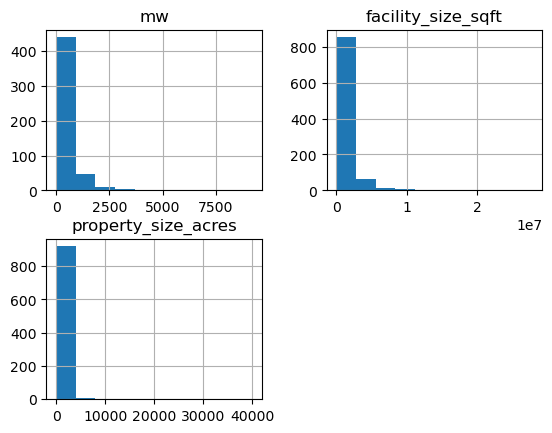

In [24]:
# Quick histogram plots for numeric columns 
df[['mw', 'facility_size_sqft', 'property_size_acres']].hist()
plt.show()

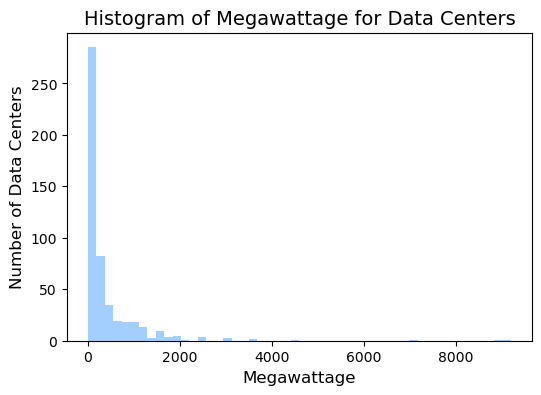

In [25]:
# Better histogram of megawattage (mw)
plt.figure(figsize = (6,4))
df['mw'].hist(bins = 50, grid = False, color = "#a2cffe")
plt.title("Histogram of Megawattage for Data Centers", fontsize = 14)
plt.ylabel("Number of Data Centers", fontsize = 12)
plt.xlabel("Megawattage", fontsize = 12)
plt.show()

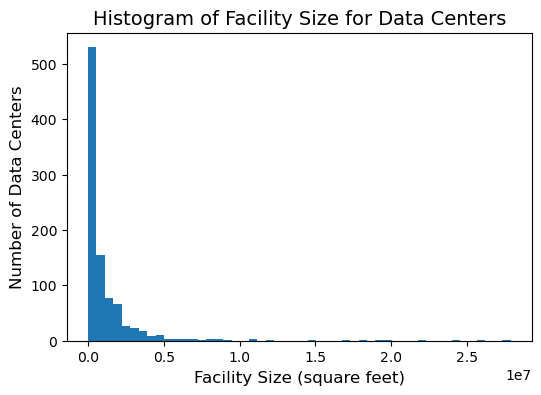

In [26]:
# Better histogram for facility size (facility_size_sqft)
plt.figure(figsize = (6,4))
df['facility_size_sqft'].hist(bins = 50, grid = False)
plt.title("Histogram of Facility Size for Data Centers", fontsize = 14)
plt.ylabel("Number of Data Centers", fontsize = 12)
plt.xlabel("Facility Size (square feet)", fontsize = 12)
plt.show()

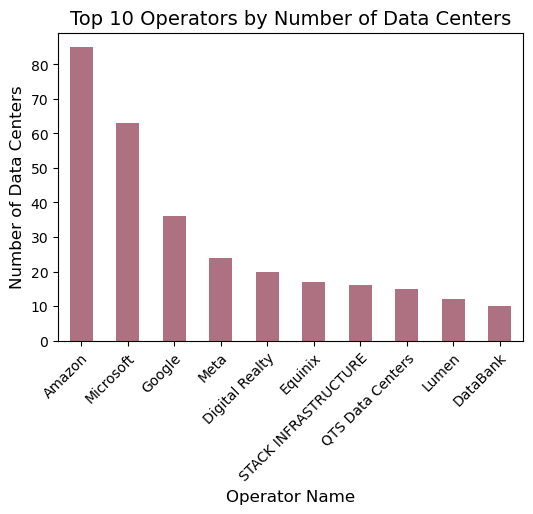

In [27]:
# Bar chart for most common data center operators
plt.figure(figsize = (6,4))
df['operator_name'].value_counts().head(10).plot(kind = "bar", color = "#ae7181")
plt.title("Top 10 Operators by Number of Data Centers", fontsize = 14)
plt.ylabel("Number of Data Centers", fontsize = 12)
plt.xlabel("Operator Name", fontsize = 12)
plt.xticks(rotation = 45, rotation_mode = "anchor", ha = "right")
plt.show()

In addition to the fairly simple graphs for data inspection shown above, it would also be interesting to see which companies are most prevalent in the top states in the dataset (i.e., the states with the most data centers); I'll visualize that below via a stacked bar chart for the pitch presentation.

In [29]:
df["state"].value_counts().head()

state
VA    458
TX    200
GA    178
PA    104
OH     61
Name: count, dtype: int64

In [30]:
# narrow down to just the top states shown above
df_top_states = df[df["state"].isin(["VA", "TX", "GA", "PA", "OH"])]

# top companies in these states
df_top_states["operator_name"].value_counts().head(10)

operator_name
Amazon                  69
Microsoft               35
Google                  21
Digital Realty          17
Equinix                 16
STACK INFRASTRUCTURE    16
Lumen                   12
QTS Data Centers        12
Meta                     8
DataBank                 8
Name: count, dtype: int64

In [31]:
# For operators not among the top 5 of the list shown above, rename that operator to Other for the visualization
org_list = ["Amazon", "Microsoft", "Google", "Digital Realty", "Equinix"]
df_top_states.loc[~df_top_states['operator_name'].isin(org_list), 'operator_name'] = "Other"

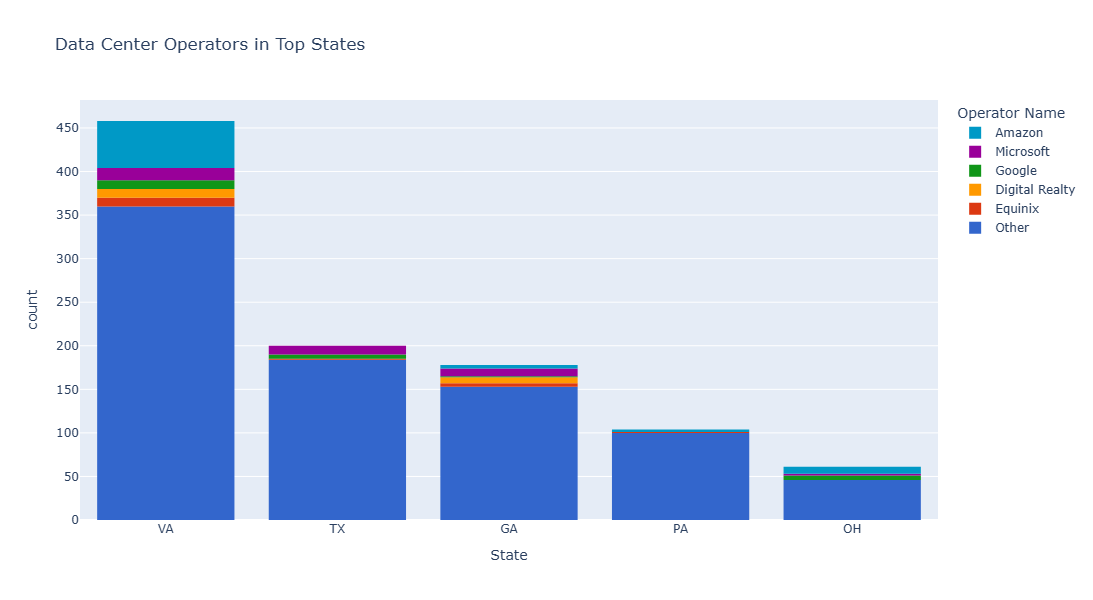

In [32]:
# Create stacked bar chart of data center operators in these five states using Plotly
# https://community.plotly.com/t/countplot-with-plotly-express/45781/7
fig = px.histogram(df_top_states, x = "state", color = "operator_name", 
                   category_orders = {"state": ["VA", "TX", "GA", "PA", "OH"],
                                     "operator_name": ["Other", "Equinix", "Digital Realty", "Google", "Microsoft", "Amazon"]}, 
                   title = "Data Center Operators in Top States", 
                   labels={
                     "state": "State",
                     "operator_name": "Operator Name"
                   },
                   color_discrete_sequence=px.colors.qualitative.G10,
                   width = 800, height = 600)

fig.update_layout(legend_traceorder = "reversed")
fig.show()

## Politics Data

There are several different sources of data related to the politics of local populations that I am considering using; I'll do an initial inspection and exploration of a few here, but I may not end up using them all moving forward. 

### American Local Government Elections Database

The American Local Government Elections Database, which can be downloaded from an [OSF repository](https://osf.io/mv5e6/overview), contains local election results at the city and county level from 1989 to 2021. The data is open access under the CC-By Attribution 4.0 International license. In the associated [Nature article](https://www.nature.com/articles/s41597-023-02792-x#Sec6) (published in 2023), the authors claim that "This is the most comprehensive publicly-available source of information on local elections across the country."

The zip file data download contains both candidate-level and constituency-level data; I'll take a look into both below. 

**Candidate-level Data**

Each row in this dataset represents a distinct candidate in a local election.

In [33]:
local_df = pd.read_csv("../Data/2021_local_politics/ledb_candidatelevel.csv")
local_df.head()

,ledb_candid,full_name,firstname,lastname,fips,geo_name,state_abb,office_consolidated,year,month,...,prob_female,prob_male,gender_est,prob_black,prob_white,prob_hispanic,prob_asian,prob_other,race_est,ballotpedia_url
0,59965,gil garcetti,gil,garcetti,06037,los angeles,CA,Prosecutor,1992,11.0,...,0.03,0.97,M,0.02,0.83,0.14,0.01,0.0,caucasian,NaN
1,59966,george gascon,george,gascon,06037,los angeles,CA,Prosecutor,2020,11.0,...,0.00,1.00,M,0.14,0.72,0.10,0.03,0.0,caucasian,NaN
2,59968,jackie lacey,jackie,lacey,06037,los angeles,CA,Prosecutor,2020,11.0,...,0.51,0.49,F,0.91,0.09,0.00,0.00,0.0,black,NaN
3,59968,jackie lacey,jackie,lacey,06037,los angeles,CA,Prosecutor,2012,11.0,...,0.51,0.49,F,0.91,0.09,0.00,0.00,0.0,black,NaN
4,7904,kim foxx,kim,foxx,17031,cook,IL,Prosecutor,2016,11.0,...,1.00,0.00,F,0.93,0.06,0.00,0.00,0.0,black,NaN


Note that the partisanship and race of some candidates is imputed. The dataset provides the number of votes for each candidate as well as whether they won or lost. As this shows various distinct political contests across time, we will need to aggregate results in some way and/or just look at most recent. 

In [34]:
print("Shape:", local_df.shape)
print("Number of states:", local_df["state_abb"].nunique()) 
print("Number of FIPS:", local_df["fips"].nunique()) 

Shape: (126599, 32)
Number of states: 53
Number of FIPS: 2632


In [35]:
local_df["state_abb"].unique()
# needs a little cleaning, e.g. has both "MD" and "Maryland"

array(['CA', 'IL', 'AZ', 'NY', 'TX', 'MI', 'FL', 'MA', 'WA', 'NV', 'OH',
       'NC', 'GA', 'MN', 'CO', 'MO', 'WI', 'MD', 'PA', 'WV', 'UT', 'NJ',
       'KS', 'KY', 'DC', 'HI', 'VA', 'OR', 'AL', 'DE', 'NM', 'IN', 'SC',
       'OK', 'IA', 'NE', 'ID', 'ME', 'TN', 'AR', 'LA', 'NH', 'MS', 'VT',
       'ND', 'MT', 'SD', 'AK', 'RI', 'WY', 'CT', 'Maryland', 'Utah'],
      dtype=object)

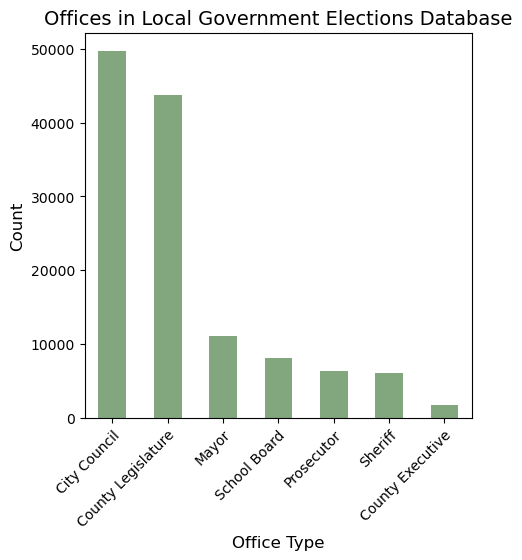

In [36]:
# Bar chart for political offices represented in dataset
plt.figure(figsize = (5,5))
local_df["office_consolidated"].value_counts().plot(kind = "bar", color = "#82a67d")
plt.title("Offices in Local Government Elections Database", fontsize = 14)
plt.ylabel("Count", fontsize = 12)
plt.xlabel("Office Type", fontsize = 12)
plt.xticks(rotation = 45, rotation_mode = "anchor", ha = "right")
plt.show()

**Constituency-level data**

Per the aforementioned Nature article, each observation in the constituency-level data is at the level of a government jurisdiction. These include data for cities (`cities_constituency_data.csv`), counties (`counties_constituency_data.csv`), school districts (`schools_districts_constituency_data.csv`), city council districts (`city_council_districts_constituency_data.csv`), and county legislative districts (`county_leg_districts_constituency_data.csv`). 

* `cities_constituency_data.csv` has demographic information about cities (w/ FIPS code) and percent voting Democrat for president in 2020, etc.
    * Per the [data table in Nature](https://www.nature.com/articles/s41597-023-02792-x/tables/3): `pres_pctD_20` is the presidential vote shares based on precinct-level data on the 2020 presidential vote
* `counties_constituency_data.csv` has the same as above but for counties 
* `city_council_districts_constituency_data.csv`: same as above but for individual city council districts
* `county_leg_districts_constituency_data.csv`: same as above but for individual county legislative districts

So, I think this is going to be less useful, since if we are interested we could get more recent presidential election data elswehere.

### National Neighborhood Data Archive

The [National Neighborhood Data Archive (NaNDA) (ICPSR 38506)](https://www.icpsr.umich.edu/web/ICPSR/studies/38506#) provides voter registration, turnout, and partisanship by county in the U.S. from 2004 to 2022. The data is public access as a TSV within a downloadable zip file with accompanying documentation, but requires having or making an account to download; I was able to sign in through Drexel. Redistribution of this dataset is not permitted. 

In [37]:
nanda_df = pd.read_csv("../Data/ICPSR_38506/DS0001/38506-0001-Data.tsv", sep = "\t")
nanda_df.head()

,STCOFIPS10,YEAR,REG_VOTERS,BALLOTS_CAST,CVAP,REG_VOTERS_PCT,VOTER_TURNOUT_PCT,REG_VOTER_TURNOUT_PCT,PRES_DEM_VOTES,PRES_REP_VOTES,SEN_DEM_VOTES,SEN_REP_VOTES,PRES_DEM_RATIO,PRES_REP_RATIO,SEN_DEM_RATIO,SEN_REP_RATIO,PARTISAN_INDEX_DEM,PARTISAN_INDEX_REP
0,1001,2000,,,,,,,4942,11993,,,.2918216586113,.7081783413887,,,,
1,1001,2002,,,,,,,,,3819,10687,,,.2632703781128,.7367296218872,,
2,1001,2004,28100,20119,34420,.816385805607,.584514796734,.715978622437,4758,15196,3960,15728,.2384484261274,.7615515589714,.2011377513409,.7988622784615,,
3,1001,2006,29724,0,36140,.822468161583,0,0,,,,,,,,,.2582950294018,.7417049407959
4,1001,2008,33536,23714,39580,.847296595573,.599141001701,.707120716572,6093,17403,5316,17941,.2593207359314,.7406792640686,.2285763472319,.771423637867,.2423373311758,.757662653923


In [39]:
nanda_df["YEAR"].value_counts().sort_index()

YEAR
2000    3112
2002    1032
2004    3114
2006    3113
2008    3114
2010    3114
2012    3114
2014    3114
2016    3114
2018    3114
2020    3115
2022    3108
Name: count, dtype: int64

The most interesting aspects of this dataset would be turnout and the Democratic/Republican partisanship indexes, which represent the % votes cast over the last six years per the documentation PDF (`38506-0001-Documentation.pdf`) that came with the data download.

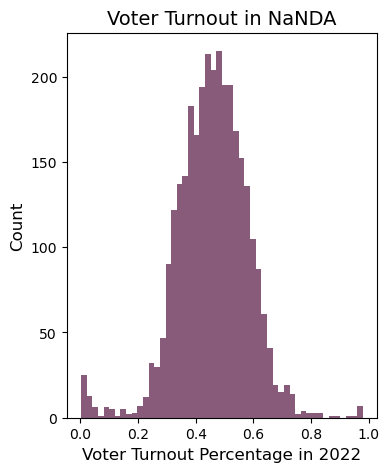

In [41]:
# Create histogram of voter turnout in 2022
nanda_df_22 = nanda_df[nanda_df["YEAR"] == 2022] # most recent year covered
nanda_turnout_22 = pd.to_numeric(nanda_df_22["VOTER_TURNOUT_PCT"], errors = "coerce")

plt.figure(figsize = (4,5))
nanda_turnout_22[nanda_turnout_22 > 0].hist(bins = 50, grid = False, color = "#895b7b")
# in above, filtering out the -1 that is presumably an error since you can't have negative voter turnout 

plt.title("Voter Turnout in NaNDA", fontsize = 14)
plt.ylabel("Count", fontsize = 12)
plt.xlabel("Voter Turnout Percentage in 2022", fontsize = 12)
plt.show()

In [42]:
print("Shape for 2022 only:", nanda_df_22.shape)
print("Number of FIPS:", nanda_df_22["STCOFIPS10"].nunique()) 

Shape for 2022 only: (3108, 18)
Number of FIPS: 3108


### MIT precinct-level data for Senate

Finally, I wanted to note that I considered using data from the MIT Election Data + Science Lab on [GitHub](https://github.com/MEDSL/2024-elections-official/tree/main), specifically the [precinct-level returns for 2024 senate](https://github.com/MEDSL/2024-elections-official/blob/main/2024-senate-county.csv). I mentioned this data in the launch presentation, but subsequently decided that the aforementioned two political datasets would be sufficient for our purposes in this project.  